In [2]:
from Bio.Seq import Seq

#Create a DNA sequence
dna=Seq("ATGCGTACGTAGCTAGCTAGCTAGCT")

#Print basic info
print("DNA Sequence",dna)
print("Length",len(dna))
print("GC content",(dna.count("G")+dna.count("C"))/len(dna)*100,"%")

#Get the complemet and reverse complement
print("Complement",dna.complement())
print("REverse Complement",dna.reverse_complement())

#Transcribe to RNA
rna=dna.transcribe()
print("RNA",rna)

#Translate to Protein
protein=dna.translate()
print("Protein",protein)


DNA Sequence ATGCGTACGTAGCTAGCTAGCTAGCT
Length 26
GC content 50.0 %
Complement TACGCATGCATCGATCGATCGATCGA
REverse Complement AGCTAGCTAGCTAGCTACGTACGCAT
RNA AUGCGUACGUAGCUAGCUAGCUAGCU
Protein MRT*LAS*


In [5]:
from Bio import Entrez, SeqIO

Entrez.email= "bhattdutt1909@gmail.com"

print("Fetching insulin gene fom NCBI...")
handle= Entrez.efetch(db="nucleotide",id="NM_000207",rettype="gb",retmode="text")
record= SeqIO.read(handle,"genbank")
handle.close()

print("Gene Name:",record.name)
print("Description:",record.description)
print("Sequence Lenght:",len(record.seq),"bp")
print("GC content:",round((record.seq.count("G")+record.seq.count("C"))/len(record.seq)*100,2),"%")

print("\n--Gene Feature")
for feature in record.features:
    print(feature.type,"->",feature.location)

Fetching insulin gene fom NCBI...
Gene Name: NM_000207
Description: Homo sapiens insulin (INS), transcript variant 1, mRNA
Sequence Lenght: 465 bp
GC content: 63.87 %

--Gene Feature
source -> [0:465](+)
gene -> [0:465](+)
exon -> [0:42](+)
exon -> [42:246](+)
CDS -> [59:392](+)
sig_peptide -> [59:131](+)
proprotein -> [131:389](+)
mat_peptide -> [131:221](+)
mat_peptide -> [227:320](+)
mat_peptide -> [326:389](+)
exon -> [246:465](+)
regulatory -> [445:451](+)
polyA_site -> [464:465](+)


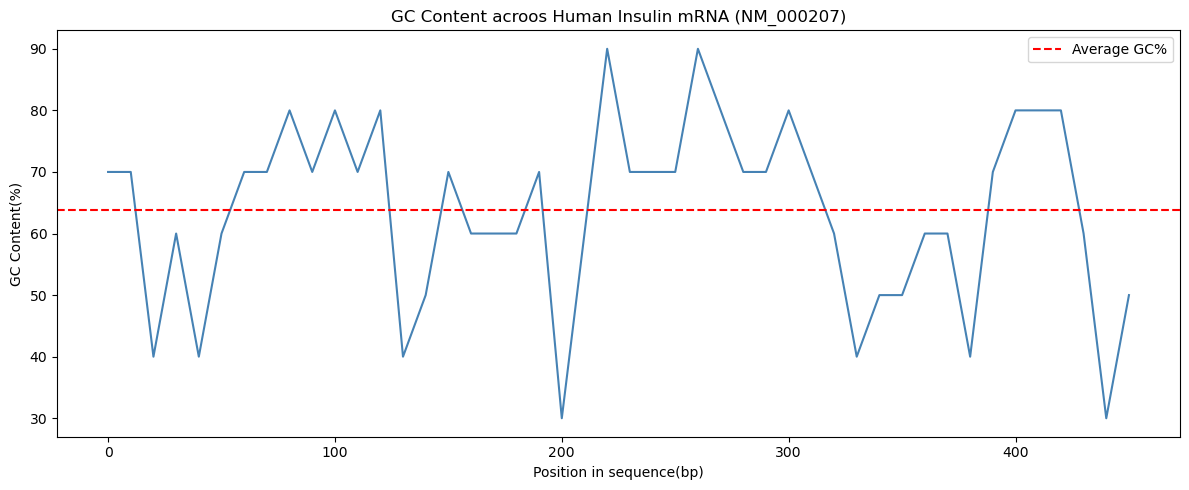

In [10]:
import matplotlib.pyplot as plt
from Bio import Entrez, SeqIO
from Bio.SeqUtils import gc_fraction

Entrez.email= "bhattdutt1909@gmail"

handle= Entrez.efetch(db="nucleotide",id="NM_000207",rettype="gb",retmode="text")
record=SeqIO.read(handle,"genbank")
handle.close()

sequence=record.seq
window_size=10
gc_value=[]
positions=[]

for i in range(0,len(sequence)-window_size,window_size):
    window= sequence[i:i+window_size]
    gc=gc_fraction(window)*100
    gc_value.append(gc)
    positions.append(i)

plt.figure(figsize=(12,5))
plt.plot(positions,gc_value,colmor="steelblue")
plt.axhline(y=63.87,color="red",linestyle="--",label="Average GC%")
plt.xlabel("Position in sequence(bp)")
plt.ylabel("GC Content(%)")
plt.title("GC Content acroos Human Insulin mRNA (NM_000207)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
from Bio import Entrez, SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

Entrez.email="bhattdutt1909@gmail.com"

handle= Entrez.efetch(db="protein",id="NP_000198",rettype="gb",retmode="text")
record= SeqIO.read(handle,"genbank")

protein_seq= str(record.seq)
print("Protein:",protein_seq)
print("Length:",len(protein_seq),"amino acids")

analysis= ProteinAnalysis(protein_seq)

print("\nAmino Acid Composition:")
aa_comp=analysis.count_amino_acids()
for aa, count in sorted(aa_comp.items()):
    print(f"{aa}:{count}")

print("\nMolecular Weight:",round(analysis.molecular_weight(),2),"Da")
print("Isoelectric Point(pI):",round(analysis.isoelectric_point(),2))
print("Instability Index:",round(analysis.instability_index(),2))
print("Is Stable??","Yes" if analysis.instability_index()<40 else "No")

Protein: MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN
Length: 110 amino acids

Amino Acid Composition:
A:10
C:6
D:2
E:8
F:3
G:12
H:2
I:2
K:2
L:20
M:2
N:3
P:6
Q:7
R:5
S:5
T:3
V:6
W:2
Y:4

Molecular Weight: 11980.79 Da
Isoelectric Point(pI): 5.22
Instability Index: 40.33
Is Stable?? No


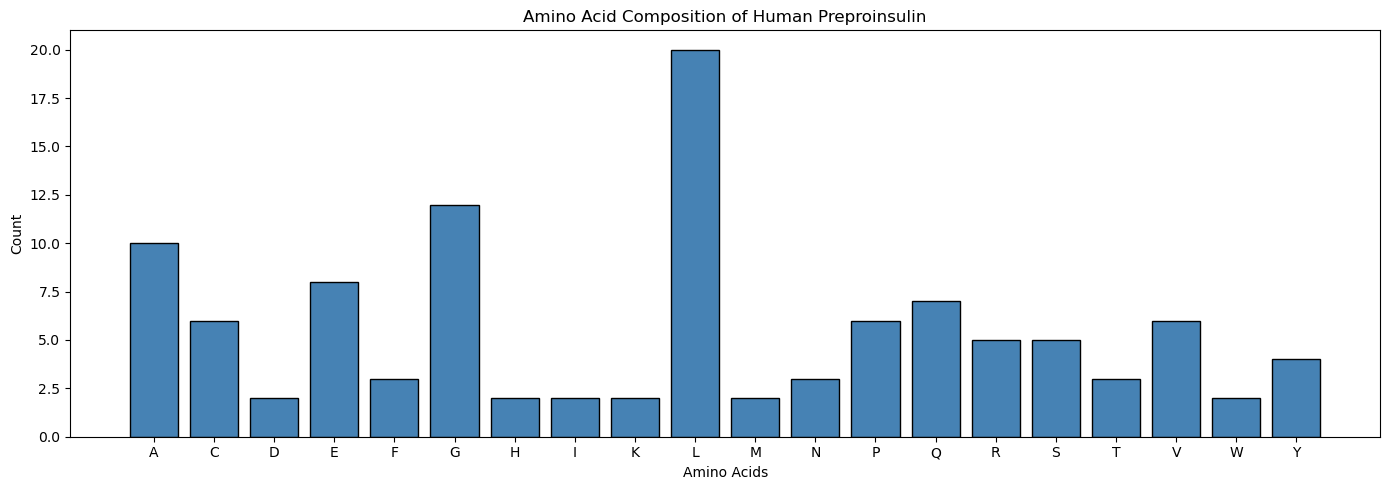

In [16]:
import matplotlib.pyplot as plt
aa_comp= analysis.count_amino_acids()

amino_acids = list(aa_comp.keys())
counts=list(aa_comp.values())

plt.figure(figsize=(14,5))
plt.bar(amino_acids,counts,color="steelblue",edgecolor="black")
plt.xlabel("Amino Acids")
plt.ylabel("Count")
plt.title("Amino Acid Composition of Human Preproinsulin")
plt.tight_layout()
plt.show()